# Task 2: Sparse Evolutionary Training (SET)

In the second task, students will implement Sparse Evolutionary Training (SET), which allows the sparse connectivity pattern to evolve during training. At regular intervals during training:
- Remove a fraction of the smallest magnitude weights
- Add the same number of new connections at random locations

This procedure maintains a constant sparsity level while enabling the network structure to adapt over time. Students should compare the performance of SET with the static sparse baseline.

## 0. Setup and Data Loading

In [6]:
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import joblib

In [7]:
# If running in Colab, uncomment these lines after uploading or mounting Drive.
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

PROJECT_DIR = "/content/drive/MyDrive/MIDS/Spring26/ECE685D_DL/final_project"
if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

print(os.listdir(PROJECT_DIR))

Mounted at /content/drive
['results', 'data']


In [8]:
results_dir = os.path.join(PROJECT_DIR, "results")

print("Results exists:", os.path.exists(results_dir))
print("Results path:", results_dir)

Results exists: True
Results path: /content/drive/MyDrive/MIDS/Spring26/ECE685D_DL/final_project/results


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_pin_memory = torch.cuda.is_available()
num_workers = min(2, os.cpu_count() or 1)

print(f"Using device: {device}")
print(f"Project directory: {PROJECT_DIR}")

Using device: cuda
Project directory: /content/drive/MyDrive/MIDS/Spring26/ECE685D_DL/final_project


In [10]:
from models import ResNetCIFAR

In [11]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ]
)

trainset = torchvision.datasets.CIFAR10(
    root=os.path.join(PROJECT_DIR, "data"),
    train=True,
    download=True,
    transform=transform,
)
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=use_pin_memory,
)

testset = torchvision.datasets.CIFAR10(
    root=os.path.join(PROJECT_DIR, "data"),
    train=False,
    download=True,
    transform=transform,
)
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=128,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=use_pin_memory,
)

classes = trainset.classes
print(f"Loaded CIFAR-10 with {len(classes)} classes.")

Loaded CIFAR-10 with 10 classes.


## 1. SET Configuration

In [12]:
sparsity_levels = [0.90, 0.95, 0.98]
optimizers = ["sgd", "adam"]
prune_fraction = 0.30
rewire_interval = 1
epochs = 15

criterion = nn.CrossEntropyLoss()
output_dir = os.path.join(PROJECT_DIR, "results")
os.makedirs(output_dir, exist_ok=True)

print(f"Sparsity levels: {sparsity_levels}")
print(f"Optimizers: {optimizers}")
print(f"Prune fraction: {prune_fraction:.2f}")
print(f"Rewire interval: every {rewire_interval} epoch(s)")
print(f"Output directory: {output_dir}")

Sparsity levels: [0.9, 0.95, 0.98]
Optimizers: ['sgd', 'adam']
Prune fraction: 0.30
Rewire interval: every 1 epoch(s)
Output directory: /content/drive/MyDrive/MIDS/Spring26/ECE685D_DL/final_project/results


In [13]:
def initialize_masks(model, sparsity):
    """Initialize binary masks for weight tensors based on target sparsity."""
    masks = {}
    for name, param in model.named_parameters():
        if "weight" in name and param.ndim > 1:
            mask = (torch.rand_like(param) > sparsity).float()
            masks[name] = mask
    return masks


def apply_masks(model, masks):
    """Zero out pruned weights by applying masks in-place."""
    with torch.no_grad():
        for name, param in model.named_parameters():
            if name in masks:
                param.mul_(masks[name])


def apply_masks_to_grads(model, masks):
    """Keep pruned connections frozen by masking their gradients."""
    for name, param in model.named_parameters():
        if name in masks and param.grad is not None:
            param.grad.mul_(masks[name])


def prune_and_regrow(model, masks, prune_fraction):
    """Magnitude prune active weights, then randomly regrow the same count."""
    with torch.no_grad():
        for name, param in model.named_parameters():
            if name not in masks:
                continue

            weights = param
            mask = masks[name]

            active_positions = mask.nonzero(as_tuple=False)
            if active_positions.numel() == 0:
                continue

            active_weights = weights[mask.bool()]
            n_prune = int(active_weights.numel() * prune_fraction)
            if n_prune < 1:
                continue

            _, prune_indices = torch.topk(
                active_weights.abs(), k=n_prune, largest=False
            )
            prune_positions = active_positions[prune_indices]
            prune_index = tuple(
                prune_positions[:, dim] for dim in range(prune_positions.size(1))
            )

            mask[prune_index] = 0.0
            weights[prune_index] = 0.0

            zero_positions = (mask == 0).nonzero(as_tuple=False)
            if zero_positions.numel() == 0:
                continue

            n_grow = min(n_prune, zero_positions.size(0))
            grow_choices = torch.randperm(
                zero_positions.size(0), device=zero_positions.device
            )[:n_grow]
            grow_positions = zero_positions[grow_choices]
            grow_index = tuple(
                grow_positions[:, dim] for dim in range(grow_positions.size(1))
            )

            mask[grow_index] = 1.0
            std = weights.std()
            if std == 0:
                std = 0.01
            weights[grow_index] = torch.randn(n_grow, device=weights.device) * std


def build_sparse_model(sparsity):
    model = ResNetCIFAR().to(device)
    masks = initialize_masks(model, sparsity)
    apply_masks(model, masks)
    return model, masks

## 2. Train and Save Results

In [ ]:
def build_optimizer(model, optimizer_type):
    if optimizer_type == "sgd":
        return optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
    if optimizer_type == "adam":
        return optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
    raise ValueError(f"Unsupported optimizer: {optimizer_type}")


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total_examples += labels.size(0)
            total_correct += predicted.eq(labels).sum().item()

    average_loss = total_loss / len(loader)
    accuracy = 100.0 * total_correct / total_examples
    return average_loss, accuracy


all_results = {}

for opt_name in optimizers:
    all_results[opt_name] = {}
    for target_sparsity in sparsity_levels:
        print(
            f"\n===== SET Run | Sparsity={target_sparsity:.2f} | Optimizer={opt_name} ====="
        )

        model, masks = build_sparse_model(target_sparsity)
        optimizer = build_optimizer(model, opt_name)
        history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

        for epoch in range(epochs):
            model.train()
            running_loss = 0.0
            correct = 0
            total = 0

            for inputs, labels in trainloader:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                apply_masks_to_grads(model, masks)
                optimizer.step()
                apply_masks(model, masks)

                running_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

            if (epoch + 1) % rewire_interval == 0:
                prune_and_regrow(model, masks, prune_fraction)
                apply_masks(model, masks)

            total_active = sum(mask.sum().item() for mask in masks.values())
            total_possible = sum(mask.numel() for mask in masks.values())
            current_sparsity = 1 - total_active / total_possible

            train_loss = running_loss / len(trainloader)
            train_acc = 100.0 * correct / total
            test_loss, test_acc = evaluate(model, testloader, criterion)

            history["train_loss"].append(train_loss)
            history["train_acc"].append(train_acc)
            history["test_loss"].append(test_loss)
            history["test_acc"].append(test_acc)

            print(
                f"Epoch [{epoch + 1}/{epochs}] | "
                f"Train Loss: {train_loss:.4f} | "
                f"Train Acc: {train_acc:.2f}% | "
                f"Test Loss: {test_loss:.4f} | "
                f"Test Acc: {test_acc:.2f}% | "
                f"Current Sparsity: {current_sparsity:.4f}"
            )

        experiment_results = {
            "sparsity": target_sparsity,
            "optimizer": opt_name,
            "method": "SET",
            "prune_fraction": prune_fraction,
            "rewire_interval": rewire_interval,
            "epochs": epochs,
            "train_loss": history["train_loss"],
            "train_acc": history["train_acc"],
            "test_loss": history["test_loss"],
            "test_acc": history["test_acc"],
            "masks": masks,
            "model_state": model.state_dict(),
        }

        results_path = os.path.join(
            PROJECT_DIR,
            "results",
            f"task_2_{opt_name}_{int(target_sparsity * 100)}_sparsity.joblib",
        )
        print("Saving to:", results_path)
        print("Exists parent folder:", os.path.exists(os.path.dirname(results_path)))
        joblib.dump(experiment_results, results_path)
        print(f"Saved results to {results_path}")

        all_results[opt_name][target_sparsity] = experiment_results

print("\nFinished all sparsity and optimizer runs.")


===== SET Run | Sparsity=0.90 | Optimizer=sgd =====
Epoch [1/15] | Train Loss: 1.4869 | Train Acc: 44.61% | Test Loss: 44.5990 | Test Acc: 10.37% | Current Sparsity: 0.8991
Epoch [2/15] | Train Loss: 1.0811 | Train Acc: 61.25% | Test Loss: 154.6319 | Test Acc: 10.47% | Current Sparsity: 0.8991
Epoch [3/15] | Train Loss: 0.9309 | Train Acc: 67.01% | Test Loss: 34.1274 | Test Acc: 14.13% | Current Sparsity: 0.8991
Epoch [4/15] | Train Loss: 0.8280 | Train Acc: 70.75% | Test Loss: 86.5423 | Test Acc: 10.00% | Current Sparsity: 0.8991
Epoch [5/15] | Train Loss: 0.7765 | Train Acc: 72.52% | Test Loss: 1.3916 | Test Acc: 52.03% | Current Sparsity: 0.8991
Epoch [6/15] | Train Loss: 0.7250 | Train Acc: 74.62% | Test Loss: 4.7413 | Test Acc: 18.09% | Current Sparsity: 0.8991
Epoch [7/15] | Train Loss: 0.6918 | Train Acc: 75.80% | Test Loss: 22.6246 | Test Acc: 13.19% | Current Sparsity: 0.8991
Epoch [8/15] | Train Loss: 0.6696 | Train Acc: 76.66% | Test Loss: 4.1258 | Test Acc: 32.61% | Curren

## 3. Analysis and Comparison

In [2]:
import os
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def infer_project_dir(start_path=None):
    """Find project root by looking for models.py and results/ folder."""
    start = Path(start_path or os.getcwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "models.py").exists() and (candidate / "results").exists():
            return str(candidate)
    return str(start)


PROJECT_DIR = infer_project_dir()
if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
os.makedirs(os.path.join(PROJECT_DIR, "img"), exist_ok=True)

print(f"Using local PROJECT_DIR: {PROJECT_DIR}")

Using local PROJECT_DIR: /Users/ammylin/Desktop/ECE685D_DL/ECE685D_Final_Project


In [3]:
import torch
import joblib

# Patch torch.load to force CPU when loading serialized tensors from joblib.
_original_torch_load = torch.load


def cpu_torch_load(*args, **kwargs):
    kwargs["map_location"] = torch.device("cpu")
    return _original_torch_load(*args, **kwargs)


torch.load = cpu_torch_load


def load_task_results(task_id, optimizers, sparsity_levels, output_dir):
    results = {opt: {} for opt in optimizers}
    for opt in optimizers:
        for s in sparsity_levels:
            file_path = os.path.join(
                output_dir,
                f"task_{task_id}_{opt}_{int(s * 100)}_sparsity.joblib",
            )
            if os.path.exists(file_path):
                results[opt][s] = joblib.load(file_path)
                print(f"Loaded: {file_path}")
            else:
                print(f"Missing: {file_path}")
    return results


analysis_dir = os.path.join(PROJECT_DIR, "results")
if not os.path.exists(analysis_dir):
    raise FileNotFoundError(
        f"Could not find local results directory at: {analysis_dir}. "
        "Set PROJECT_DIR to your project root if needed."
    )

analysis_sparsities = list(globals().get("sparsity_levels", [0.90, 0.95, 0.98]))
analysis_opts = list(globals().get("optimizers", ["sgd", "adam"]))

results_task_1 = load_task_results(1, analysis_opts, analysis_sparsities, analysis_dir)
results_task_2 = load_task_results(2, analysis_opts, analysis_sparsities, analysis_dir)

Loaded: /Users/ammylin/Desktop/ECE685D_DL/ECE685D_Final_Project/results/task_1_sgd_90_sparsity.joblib
Loaded: /Users/ammylin/Desktop/ECE685D_DL/ECE685D_Final_Project/results/task_1_sgd_95_sparsity.joblib
Loaded: /Users/ammylin/Desktop/ECE685D_DL/ECE685D_Final_Project/results/task_1_sgd_98_sparsity.joblib
Loaded: /Users/ammylin/Desktop/ECE685D_DL/ECE685D_Final_Project/results/task_1_adam_90_sparsity.joblib
Loaded: /Users/ammylin/Desktop/ECE685D_DL/ECE685D_Final_Project/results/task_1_adam_95_sparsity.joblib
Loaded: /Users/ammylin/Desktop/ECE685D_DL/ECE685D_Final_Project/results/task_1_adam_98_sparsity.joblib
Loaded: /Users/ammylin/Desktop/ECE685D_DL/ECE685D_Final_Project/results/task_2_sgd_90_sparsity.joblib
Loaded: /Users/ammylin/Desktop/ECE685D_DL/ECE685D_Final_Project/results/task_2_sgd_95_sparsity.joblib
Loaded: /Users/ammylin/Desktop/ECE685D_DL/ECE685D_Final_Project/results/task_2_sgd_98_sparsity.joblib
Loaded: /Users/ammylin/Desktop/ECE685D_DL/ECE685D_Final_Project/results/task_2_

In [4]:
def plot_training_and_validation(results, task_label="Task 2 (SET)"):
    for s in analysis_sparsities:
        rows = []

        for opt in analysis_opts:
            if s in results[opt]:
                n_epochs = len(results[opt][s]["train_loss"])
                for epoch in range(n_epochs):
                    rows.append(
                        {
                            "epoch": epoch + 1,
                            "optimizer": opt.upper(),
                            "split": "Train",
                            "loss": results[opt][s]["train_loss"][epoch],
                            "accuracy": results[opt][s]["train_acc"][epoch],
                        }
                    )
                    rows.append(
                        {
                            "epoch": epoch + 1,
                            "optimizer": opt.upper(),
                            "split": "Test",
                            "loss": results[opt][s]["test_loss"][epoch],
                            "accuracy": results[opt][s]["test_acc"][epoch],
                        }
                    )

        if not rows:
            print(f"No runs available for sparsity={s:.2f}")
            continue

        df = pd.DataFrame(rows)

        fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
        fig.suptitle(
            f"{task_label}: Training Dynamics at {int(s * 100)}% Sparsity",
            fontsize=16,
            weight="bold",
        )

        sns.lineplot(
            data=df[df["split"] == "Train"],
            x="epoch",
            y="loss",
            hue="optimizer",
            linewidth=2.2,
            ax=axes[0, 0],
        )
        axes[0, 0].set_title("Train Loss")
        axes[0, 0].set_ylabel("Loss")
        axes[0, 0].legend(title="")

        sns.lineplot(
            data=df[df["split"] == "Test"],
            x="epoch",
            y="loss",
            hue="optimizer",
            linewidth=2.2,
            ax=axes[0, 1],
        )
        axes[0, 1].set_title("Test Loss")
        axes[0, 1].set_ylabel("Loss")
        axes[0, 1].legend(title="")

        sns.lineplot(
            data=df[df["split"] == "Train"],
            x="epoch",
            y="accuracy",
            hue="optimizer",
            linewidth=2.2,
            ax=axes[1, 0],
        )
        axes[1, 0].set_title("Train Accuracy")
        axes[1, 0].set_xlabel("Epoch")
        axes[1, 0].set_ylabel("Accuracy (%)")
        axes[1, 0].legend(title="")

        sns.lineplot(
            data=df[df["split"] == "Test"],
            x="epoch",
            y="accuracy",
            hue="optimizer",
            linewidth=2.2,
            ax=axes[1, 1],
        )
        axes[1, 1].set_title("Test Accuracy")
        axes[1, 1].set_xlabel("Epoch")
        axes[1, 1].set_ylabel("Accuracy (%)")
        axes[1, 1].legend(title="")

        for ax in axes.flat:
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(
            os.path.join(PROJECT_DIR, "img", f"task_2_curves_{int(s * 100)}.png"),
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

In [5]:
def plot_accuracy_vs_sparsity(results, task_label="Task 2 (SET)"):
    rows = []
    for opt in analysis_opts:
        for s in analysis_sparsities:
            if s in results[opt]:
                rows.append(
                    {
                        "optimizer": opt.upper(),
                        "sparsity": int(s * 100),
                        "final_test_acc": results[opt][s]["test_acc"][-1],
                    }
                )

    if not rows:
        print("No data available for accuracy-vs-sparsity plot.")
        return None

    df = pd.DataFrame(rows)

    plt.figure(figsize=(6, 4))
    ax = sns.lineplot(
        data=df,
        x="sparsity",
        y="final_test_acc",
        hue="optimizer",
        marker="o",
        linewidth=2.4,
    )

    for _, row in df.iterrows():
        ax.text(
            row["sparsity"],
            row["final_test_acc"],
            f"{row['final_test_acc']:.1f}",
            fontsize=8,
            ha="center",
            va="bottom",
        )

    ax.set_title(f"{task_label}: Final Test Accuracy vs Sparsity", weight="bold")
    ax.set_xlabel("Sparsity (%)")
    ax.set_ylabel("Final Test Accuracy (%)")
    ax.set_xticks([90, 95, 98])
    ax.legend(title="")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        os.path.join(PROJECT_DIR, "img", "task_2_accuracy_vs_sparsity.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    return df.sort_values(["optimizer", "sparsity"]).reset_index(drop=True)

In [6]:
def compare_task1_vs_task2(results_task_1, results_task_2):
    rows = []
    for opt in analysis_opts:
        for s in analysis_sparsities:
            if s in results_task_1[opt] and s in results_task_2[opt]:
                baseline_acc = results_task_1[opt][s]["test_acc"][-1]
                set_acc = results_task_2[opt][s]["test_acc"][-1]
                rows.append(
                    {
                        "optimizer": opt.upper(),
                        "sparsity": int(s * 100),
                        "task_1_static": baseline_acc,
                        "task_2_set": set_acc,
                        "delta_set_minus_static": set_acc - baseline_acc,
                    }
                )

    if not rows:
        print("No overlapping Task 1/Task 2 runs found.")
        return None

    df = (
        pd.DataFrame(rows).sort_values(["optimizer", "sparsity"]).reset_index(drop=True)
    )

    long_df = df.melt(
        id_vars=["optimizer", "sparsity"],
        value_vars=["task_1_static", "task_2_set"],
        var_name="method",
        value_name="final_test_acc",
    )
    long_df["method"] = long_df["method"].map(
        {"task_1_static": "Task 1 Static", "task_2_set": "Task 2 SET"}
    )

    plt.figure(figsize=(8, 4.5))
    ax = sns.barplot(
        data=long_df,
        x="sparsity",
        y="final_test_acc",
        hue="method",
        errorbar=None,
    )
    ax.set_title("Task 1 vs Task 2: Final Test Accuracy", weight="bold")
    ax.set_xlabel("Sparsity (%)")
    ax.set_ylabel("Final Test Accuracy (%)")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(title="")
    plt.tight_layout()
    plt.savefig(
        os.path.join(PROJECT_DIR, "img", "task_1_vs_task_2_accuracy.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    delta_pivot = df.pivot(
        index="sparsity", columns="optimizer", values="delta_set_minus_static"
    )
    plt.figure(figsize=(6, 3.8))
    sns.heatmap(
        delta_pivot,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",
        center=0,
        cbar_kws={"label": "SET - Static Accuracy (pp)"},
    )
    plt.title("SET Gain/Loss Over Static Sparse Baseline", weight="bold")
    plt.xlabel("Optimizer")
    plt.ylabel("Sparsity (%)")
    plt.tight_layout()
    plt.savefig(
        os.path.join(PROJECT_DIR, "img", "task_2_delta_heatmap.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    return df

### Layer- and Component-Level Sparsity

This block computes sparsity statistics directly from the saved binary masks.

What it does:
- Classifies each layer as `conv`, `fc`, or `other` from the layer name.
- Computes per-layer sparsity using
  $\text{sparsity} = 1 - \frac{\|W\|_0}{|W|}$
  where $\|W\|_0$ is the number of active (nonzero) mask entries.
- Aggregates to component-level sparsity (conv/fc/other) for easier comparison.

How to read the plot:
- Higher bar means more sparse (fewer active connections).
- Compare Task 1 vs Task 2 at the same optimizer/sparsity to see where SET changes connectivity distribution.

In [7]:
def layer_type_from_name(name):
    lname = name.lower()
    if "conv" in lname:
        return "conv"
    if "fc" in lname or "linear" in lname:
        return "fc"
    return "other"


def build_layer_sparsity_table(results, method_label):
    rows = []
    for opt in analysis_opts:
        for s in analysis_sparsities:
            run = results.get(opt, {}).get(s)
            if run is None:
                continue

            masks = run.get("masks", {})
            for layer_name, mask in masks.items():
                total = int(mask.numel())
                active = int(torch.count_nonzero(mask).item())
                sparsity = 1.0 - (active / total)
                rows.append(
                    {
                        "method": method_label,
                        "optimizer": opt.upper(),
                        "sparsity_target": int(s * 100),
                        "layer": layer_name,
                        "layer_type": layer_type_from_name(layer_name),
                        "active_weights": active,
                        "total_weights": total,
                        "actual_sparsity": sparsity,
                    }
                )

    if not rows:
        return pd.DataFrame()

    return pd.DataFrame(rows)


def component_summary(layer_df):
    if layer_df.empty:
        return pd.DataFrame()

    grouped = layer_df.groupby(
        ["method", "optimizer", "sparsity_target", "layer_type"], as_index=False
    ).agg(
        active_weights=("active_weights", "sum"),
        total_weights=("total_weights", "sum"),
    )
    grouped["actual_sparsity"] = 1.0 - (
        grouped["active_weights"] / grouped["total_weights"]
    )
    return grouped.sort_values(["method", "optimizer", "sparsity_target", "layer_type"])


def plot_component_sparsity(comp_df):
    if comp_df.empty:
        print("No component-level sparsity data available.")
        return

    plot_df = comp_df.copy()
    plot_df["actual_sparsity_pct"] = plot_df["actual_sparsity"] * 100
    plot_df["config"] = (
        plot_df["method"]
        + " | "
        + plot_df["optimizer"]
        + " | "
        + plot_df["sparsity_target"].astype(str)
        + "%"
    )

    plt.figure(figsize=(12, 5))
    ax = sns.barplot(
        data=plot_df,
        x="config",
        y="actual_sparsity_pct",
        hue="layer_type",
    )
    ax.set_title("Component-Wise Sparsity (Conv vs FC vs Other)", weight="bold")
    ax.set_xlabel("Method | Optimizer | Target Sparsity")
    ax.set_ylabel("Actual Sparsity (%)")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(title="Layer Type")
    plt.tight_layout()
    plt.savefig(
        os.path.join(PROJECT_DIR, "img", "task_2_component_sparsity.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

### Connectivity Similarity and Evolution

This block quantifies how similar connectivity patterns are across methods and over time.

Metrics used:
- **Mask Jaccard similarity** between two masks:
  $J(A,B)=\frac{|A\cap B|}{|A\cup B|}$
- $J=1$ means identical active connections; lower values mean larger topology differences.

What is reported:
- **Task 1 vs Task 2 overlap** at the end of training (heatmap by optimizer and sparsity).
- **Epoch-to-epoch evolution** for Task 2 if `mask_history` exists in saved results.

Interpretation:
- Lower Task1-vs-Task2 Jaccard suggests SET found a different connectivity structure than static sparse training.
- Lower epoch-to-epoch Jaccard suggests more aggressive topology rewiring during SET.

In [8]:
def mask_jaccard(mask_a, mask_b):
    a = mask_a.bool()
    b = mask_b.bool()
    inter = torch.logical_and(a, b).sum().item()
    union = torch.logical_or(a, b).sum().item()
    if union == 0:
        return 1.0
    return inter / union


def connectivity_overlap_task1_vs_task2(results_task_1, results_task_2):
    rows = []
    for opt in analysis_opts:
        for s in analysis_sparsities:
            run1 = results_task_1.get(opt, {}).get(s)
            run2 = results_task_2.get(opt, {}).get(s)
            if run1 is None or run2 is None:
                continue

            masks1 = run1.get("masks", {})
            masks2 = run2.get("masks", {})
            common_layers = sorted(set(masks1.keys()).intersection(masks2.keys()))
            if not common_layers:
                continue

            layer_scores = []
            for layer in common_layers:
                score = mask_jaccard(masks1[layer], masks2[layer])
                layer_scores.append(score)
                rows.append(
                    {
                        "optimizer": opt.upper(),
                        "sparsity_target": int(s * 100),
                        "layer": layer,
                        "mask_jaccard": score,
                    }
                )

            rows.append(
                {
                    "optimizer": opt.upper(),
                    "sparsity_target": int(s * 100),
                    "layer": "__OVERALL__",
                    "mask_jaccard": float(sum(layer_scores) / len(layer_scores)),
                }
            )

    if not rows:
        return pd.DataFrame(), pd.DataFrame()

    overlap_df = pd.DataFrame(rows)
    overall_df = overlap_df[overlap_df["layer"] == "__OVERALL__"].copy()
    return overlap_df, overall_df


def plot_connectivity_overlap(overall_df):
    if overall_df.empty:
        print("No overlap data available for Task 1 vs Task 2 connectivity.")
        return

    pivot = overall_df.pivot(
        index="sparsity_target", columns="optimizer", values="mask_jaccard"
    )

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".3f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        cbar_kws={"label": "Mask Jaccard Similarity"},
    )
    plt.title("Connectivity Overlap: Task 1 Static vs Task 2 SET", weight="bold")
    plt.xlabel("Optimizer")
    plt.ylabel("Target Sparsity (%)")
    plt.tight_layout()
    plt.savefig(
        os.path.join(PROJECT_DIR, "img", "task_2_connectivity_overlap_heatmap.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


def analyze_mask_history_evolution(results_task_2):
    rows = []
    for opt in analysis_opts:
        for s in analysis_sparsities:
            run = results_task_2.get(opt, {}).get(s)
            if run is None or "mask_history" not in run:
                continue

            history = run["mask_history"]
            if len(history) < 2:
                continue

            for epoch_idx in range(1, len(history)):
                prev_masks = history[epoch_idx - 1]
                curr_masks = history[epoch_idx]
                common_layers = sorted(
                    set(prev_masks.keys()).intersection(curr_masks.keys())
                )
                if not common_layers:
                    continue

                per_layer = [
                    mask_jaccard(prev_masks[l], curr_masks[l]) for l in common_layers
                ]
                rows.append(
                    {
                        "optimizer": opt.upper(),
                        "sparsity_target": int(s * 100),
                        "epoch": epoch_idx + 1,
                        "mean_jaccard_prev_epoch": float(
                            sum(per_layer) / len(per_layer)
                        ),
                    }
                )

    return pd.DataFrame(rows)


def plot_mask_history_evolution(evolution_df):
    if evolution_df.empty:
        print(
            "No `mask_history` found in saved results, so epoch-wise connectivity evolution "
            "cannot be computed from current files."
        )
        print("You can enable it by saving a mask snapshot each epoch during training.")
        return

    plt.figure(figsize=(8, 4.5))
    sns.lineplot(
        data=evolution_df,
        x="epoch",
        y="mean_jaccard_prev_epoch",
        hue="optimizer",
        style="sparsity_target",
        marker="o",
    )
    plt.ylim(0, 1)
    plt.title(
        "SET Connectivity Evolution (Mask Similarity to Previous Epoch)", weight="bold"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Mean Layer Jaccard with Previous Epoch")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        os.path.join(PROJECT_DIR, "img", "task_2_connectivity_evolution.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

### Run All Analysis and Summaries

This final cell executes the full analysis pipeline and prints compact tables for reporting.

Outputs generated:
- Training/validation dynamics (Task 2)
- Accuracy vs sparsity (Task 2)
- Task 1 vs Task 2 final-accuracy comparison
- Component-level sparsity summary
- Connectivity overlap summary
- Optional epoch-wise connectivity evolution (if `mask_history` is available)

Saved figures are written to the `img/` folder.

CHUNK 1: Training Dynamics Visualization


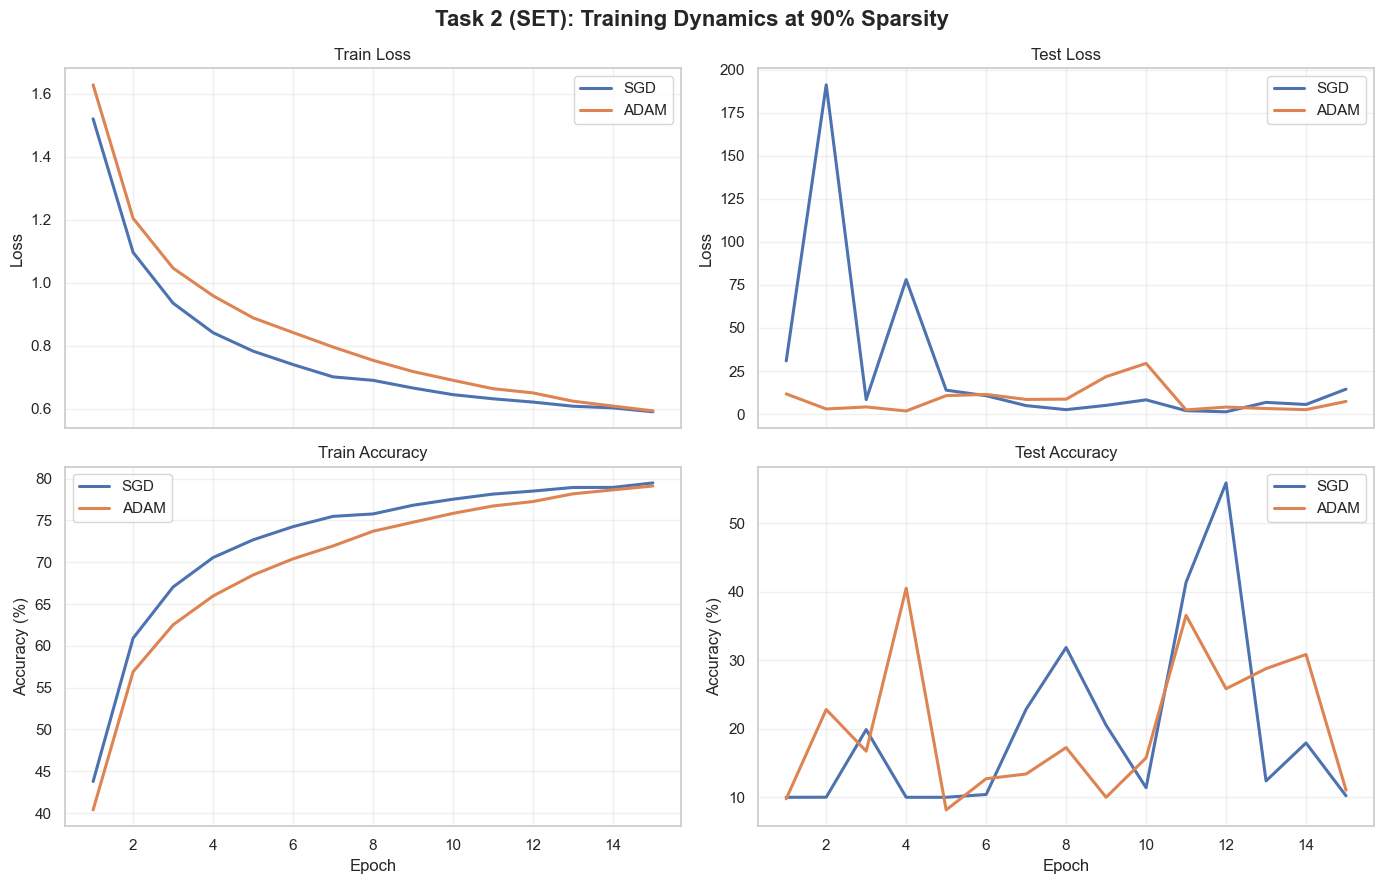

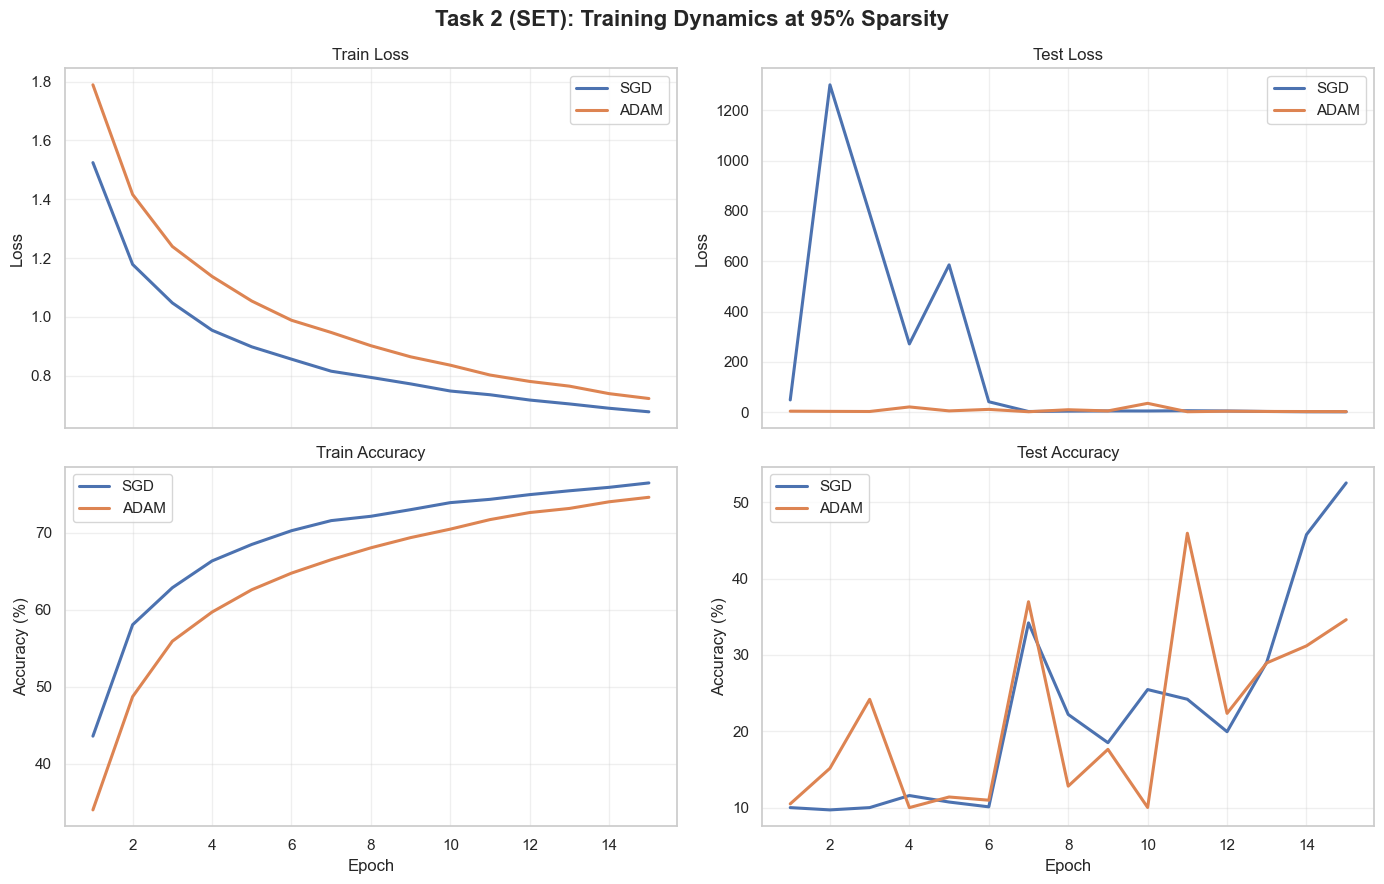

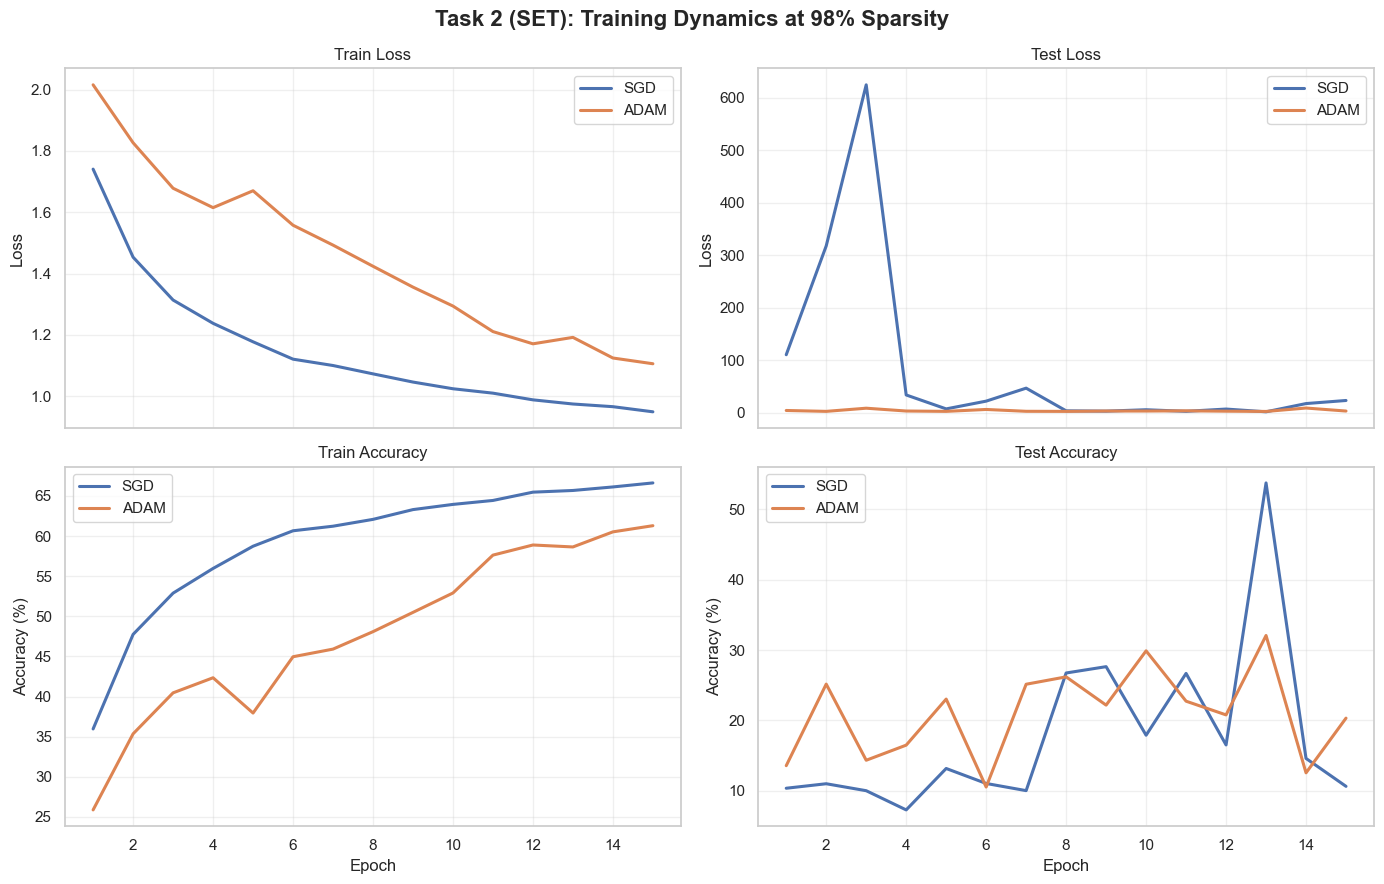

✓ Training dynamics completed

CHUNK 2: Accuracy Analysis


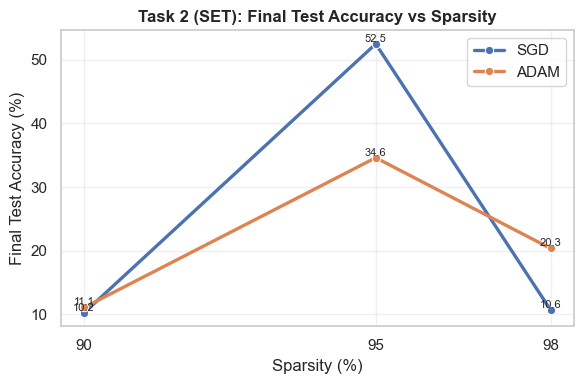

✓ Task 2 accuracy plot completed


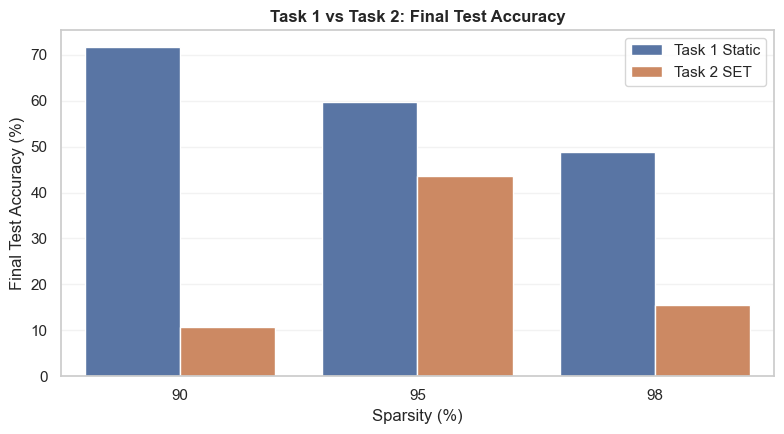

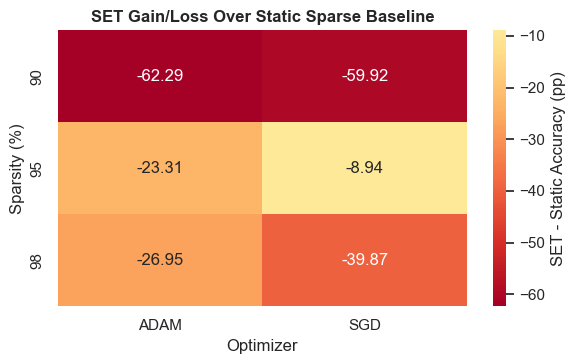

In [ ]:
import gc

# Chunk 1: Training dynamics
print("=" * 60)
print("CHUNK 1: Training Dynamics Visualization")
print("=" * 60)
try:
    plot_training_and_validation(results_task_2, task_label="Task 2 (SET)")
    gc.collect()
    print("✓ Training dynamics completed")
except Exception as e:
    print(f"✗ Training dynamics failed: {e}")

# Chunk 2: Accuracy summaries
print("\n" + "=" * 60)
print("CHUNK 2: Accuracy Analysis")
print("=" * 60)
try:
    task2_summary = plot_accuracy_vs_sparsity(results_task_2, task_label="Task 2 (SET)")
    gc.collect()
    print("✓ Task 2 accuracy plot completed")
except Exception as e:
    print(f"✗ Task 2 accuracy plot failed: {e}")
    task2_summary = None

try:
    comparison_df = compare_task1_vs_task2(results_task_1, results_task_2)
    gc.collect()
    print("✓ Task comparison completed")
except Exception as e:
    print(f"✗ Task comparison failed: {e}")
    comparison_df = None

# Chunk 3: Component sparsity
print("\n" + "=" * 60)
print("CHUNK 3: Component Sparsity Analysis")
print("=" * 60)
try:
    layer_df_task1 = build_layer_sparsity_table(
        results_task_1, method_label="Task 1 Static"
    )
    layer_df_task2 = build_layer_sparsity_table(
        results_task_2, method_label="Task 2 SET"
    )
    layer_df_all = pd.concat([layer_df_task1, layer_df_task2], ignore_index=True)
    component_df = component_summary(layer_df_all)
    plot_component_sparsity(component_df)
    gc.collect()
    print("✓ Component sparsity analysis completed")
except Exception as e:
    print(f"✗ Component sparsity analysis failed: {e}")
    component_df = pd.DataFrame()

# Chunk 4: Connectivity overlap
print("\n" + "=" * 60)
print("CHUNK 4: Connectivity Overlap Analysis")
print("=" * 60)
try:
    _, connectivity_overall_df = connectivity_overlap_task1_vs_task2(
        results_task_1, results_task_2
    )
    plot_connectivity_overlap(connectivity_overall_df)
    gc.collect()
    print("✓ Connectivity overlap analysis completed")
except Exception as e:
    print(f"✗ Connectivity overlap analysis failed: {e}")
    connectivity_overall_df = pd.DataFrame()

# Chunk 5: Summary tables
print("\n" + "=" * 60)
print("CHUNK 5: Summary Tables")
print("=" * 60)

if task2_summary is not None:
    print("\nTask 2 final accuracy summary:")
    display(task2_summary)

if comparison_df is not None:
    print("\nTask 1 vs Task 2 comparison (positive delta means SET is better):")
    display(comparison_df)
    print("\nAverage delta by optimizer:")
    display(
        comparison_df.groupby("optimizer", as_index=False)[
            "delta_set_minus_static"
        ].mean()
    )

if not component_df.empty:
    print("\nComponent-wise sparsity summary:")
    display(component_df)

if not connectivity_overall_df.empty:
    print("\nConnectivity overlap summary (Task 1 vs Task 2):")
    display(connectivity_overall_df)

print("\n" + "=" * 60)
print("Analysis pipeline completed")
print("=" * 60)